# Model Evaluation Plan
The main purpose of this notebook to use baseline models to test the full evaluation process, that means, the evaluation plan was created before final modeling to define a fair and leakage-free modeling workflow. This step is important because model performance can be misleading if the data split, metrics, leakage checks, and test-set rules are not defined in advance. For this checkpoint, baseline models were evaluated using the planned framework. More advanced modeling and hyperparameter tuning will be performed later using the same evaluation structure.

## Evaluation Framework
* Split the data
* Train models using cross-validation
* Compare recall, PR-AUC, ROC-AUC, balanced accuracy, F1
* Select a model
* Evaluate it on final holdout test set
* Show classification report
* Show confusion matrix
* Show ROC and PR curves
* Run shuffled-target check
* Run subgroup performance check
  
## Unit of Analysis

Each row in the cleaned NHANES dataset represents one adult participant. The prediction task is participant-level diabetes risk screening, where the target variable is `diabetes`.

## Split Strategy

Because the outcome variable is moderately imbalanced, a stratified splitting strategy is used. A final holdout test set is separated first using stratified train-test splitting so that the diabetes and non-diabetes proportions are preserved in both training and test sets.

Model comparison is performed only on the training set using stratified 5-fold cross-validation. The final test set is kept untouched during model comparison and is used only once after selecting the final model.

## Leakage Prevention

Variables directly used to construct the diabetes target are excluded from the predictor set. These include self-reported diabetes diagnosis, HbA1c, fasting glucose, and the derived doctor-diagnosis indicator. The participant identifier is also removed because it is not a meaningful predictor.

All preprocessing steps, including imputation, scaling, and one-hot encoding, are performed inside scikit-learn pipelines. This prevents train-test contamination because preprocessing is fit only on the training folds during cross-validation.

## Metrics

Because this is an early diabetes screening problem, accuracy alone is not sufficient. The primary goal is to identify as many diabetes cases as possible, so recall for the diabetes class is treated as the primary metric.

The following metrics are used:

* Recall
* PR-AUC
* ROC-AUC
* Balanced accuracy
* F1-score
* Precision
* Accuracy
* Confusion matrix
* Classification report

Recall and PR-AUC are emphasized because the diabetes class is less frequent than the non-diabetes class.

## Baseline Models

The following baseline models are evaluated:

* Dummy Classifier
* Logistic Regression
* Decision Tree

The Dummy Classifier provides a majority-class reference model. Logistic Regression serves as a simple and interpretable linear baseline. The Decision Tree provides a simple nonlinear baseline that can capture basic feature interactions.

## Planned Stress Tests

Additional stress tests will be considered after baseline evaluation:

* Subgroup performance by age group, gender, race/ethnicity, and education
* Shuffled-target leakage check
* Outlier sensitivity analysis
* Calibration analysis for predicted probabilities

At this checkpoint, the main goal is to run baseline models through a consistent evaluation framework.


In [18]:
#Import Library 

import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    make_scorer,
    recall_score,
    precision_score,
    f1_score,
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

In [19]:
#Load dataset 
processed_dir = Path("D:\Erdos\Data Science Bootcamp\summer26-diabetes-risk\early_diabetes_screening\data\processed")
X = pd.read_csv(processed_dir / "X_pred_engineered.csv")
y = pd.read_csv(processed_dir / "y_target_selected.csv").squeeze()
print("Predictor shape", X.shape)
print("Target shape", y.shape)
X.head()

Predictor shape (9232, 37)
Target shape (9232,)


,RIDAGEYR,RIAGENDR,RIDRETH3,DMDEDUC2,INDFMPIR,BMXBMI,BMXWAIST,BPQ020,BPQ080,SMQ020,...,high_waist,physically_active,ever_regular_alcohol,smoking_history,fair_poor_diet,frequent_fast_food,age_bmi,age_waist,age_systolic_bp,metabolic_risk_score
0,29.0,2.0,6.0,5.0,5.00,37.8,117.9,2.0,1.0,2.0,...,1.0,1.0,1.0,0.0,0.0,1.0,1096.2,3419.1,2871.0,2.0
1,21.0,2.0,2.0,4.0,5.00,NaN,NaN,2.0,2.0,2.0,...,NaN,1.0,NaN,0.0,0.0,1.0,NaN,NaN,NaN,0.0
2,49.0,1.0,3.0,2.0,NaN,29.7,120.4,2.0,1.0,1.0,...,1.0,0.0,1.0,1.0,0.0,0.0,1455.3,5899.6,5243.0,2.0
3,36.0,1.0,3.0,4.0,0.83,21.9,86.8,2.0,2.0,1.0,...,0.0,1.0,1.0,1.0,1.0,0.0,788.4,3124.8,4092.0,2.0
4,68.0,1.0,7.0,4.0,1.20,30.2,109.6,1.0,1.0,2.0,...,1.0,1.0,1.0,0.0,0.0,0.0,2053.6,7452.8,9112.0,3.0


In [20]:
results_dir = Path(r"D:\Erdos\Data Science Bootcamp\summer26-diabetes-risk\early_diabetes_screening\results")
results_dir.mkdir(parents=True, exist_ok=True)
modeling_dir = results_dir / "modeling"
modeling_dir.mkdir(parents=True, exist_ok=True)

In [21]:
# Stratified final holdout split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(4))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).round(4))

Training set shape: (7385, 37)
Test set shape: (1847, 37)

Training target distribution:
diabetes
0    0.8028
1    0.1972
Name: proportion, dtype: float64

Test target distribution:
diabetes
0    0.8029
1    0.1971
Name: proportion, dtype: float64


### Stratified Train-Test Split

An 80/20 stratified train-test split was used to create the training set and the final holdout test set. The training set contains 7,385 participants, and the test set contains 1,847 participants.

Stratification was used because the diabetes target is moderately imbalanced. The training set contains approximately 80.28% non-diabetes cases and 19.72% diabetes cases. The test set contains approximately 80.29% non-diabetes cases and 19.71% diabetes cases.

The nearly identical class proportions show that the stratified split preserved the original diabetes/non-diabetes distribution in both sets. This makes the split appropriate for evaluating an imbalanced diabetes screening model.

In [22]:
# Define categoric and numeric features 

coded_categorical_features = [
    # Original coded categorical variables
    "RIAGENDR",
    "RIDRETH3",
    "DMDEDUC2",
    "BPQ020",
    "BPQ080",
    "SMQ020",
    "PAQ650",
    "PAQ665",
    "ALQ111",
    "ALQ121",
    "DBQ700",
    
    # Engineered categorical / binary indicator variables
    "obese",
    "bmi_category",
    "high_bp_exam",
    "high_waist",
    "physically_active",
    "ever_regular_alcohol",
    "smoking_history",
    "fair_poor_diet",
    "fair_or_poor_diet",
    "frequent_fast_food"
]

categorical_features = [
    col for col in coded_categorical_features
    if col in X_train.columns
]

object_categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

categorical_features = sorted(list(set(categorical_features + object_categorical_features)))

numeric_features = [
    col for col in X_train.columns
    if col not in categorical_features
]

print("Number of numeric features:", len(numeric_features))
print(numeric_features)

print("\nNumber of categorical features:", len(categorical_features))
print(categorical_features)

Number of numeric features: 17
['RIDAGEYR', 'INDFMPIR', 'BMXBMI', 'BMXWAIST', 'PAD680', 'ALQ130', 'DBD895', 'DBD900', 'DBD905', 'DBD910', 'avg_systolic_bp', 'avg_diastolic_bp', 'pulse_pressure', 'age_bmi', 'age_waist', 'age_systolic_bp', 'metabolic_risk_score']

Number of categorical features: 20
['ALQ111', 'ALQ121', 'BPQ020', 'BPQ080', 'DBQ700', 'DMDEDUC2', 'PAQ650', 'PAQ665', 'RIAGENDR', 'RIDRETH3', 'SMQ020', 'bmi_category', 'ever_regular_alcohol', 'fair_poor_diet', 'frequent_fast_food', 'high_bp_exam', 'high_waist', 'obese', 'physically_active', 'smoking_history']


In [23]:
# Preprocessing pipeline 

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [24]:
# Define baseline models 
models = {
    "Dummy Classifier": DummyClassifier(
        strategy="most_frequent"
    ),
    
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=42
    )
}

In [25]:
# Define metrics and cross-validations 

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "recall": make_scorer(recall_score),
    "precision": make_scorer(precision_score, zero_division=0),
    "f1": make_scorer(f1_score)
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [26]:
# Cross validation on trainning set 

cv_results_list = []

for model_name, model in models.items():
    print(f"Running cross-validation for: {model_name}")
    
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )
    
    row = {
        "model": model_name,
        "split_strategy": "80_20_stratified_holdout_with_5fold_stratified_cv_on_training"
    }
    
    for metric in scoring.keys():
        scores = cv_results[f"test_{metric}"]
        row[f"{metric}_mean"] = scores.mean()
        row[f"{metric}_std"] = scores.std()
    
    cv_results_list.append(row)
    
cv_results_df = pd.DataFrame(cv_results_list)
cv_results_df

Running cross-validation for: Dummy Classifier
Running cross-validation for: Logistic Regression
Running cross-validation for: Decision Tree


,model,split_strategy,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,recall_mean,recall_std,precision_mean,precision_std,f1_mean,f1_std
0,Dummy Classifier,80_20_stratified_holdout_with_5fold_stratified...,0.802844,0.000271,0.500000,0.000000,0.500000,0.000000,0.197156,0.000271,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,Logistic Regression,80_20_stratified_holdout_with_5fold_stratified...,0.716723,0.003547,0.730046,0.006979,0.805430,0.008478,0.479989,0.011408,0.752048,0.016208,0.387462,0.004708,0.511398,0.007113
2,Decision Tree,80_20_stratified_holdout_with_5fold_stratified...,0.670819,0.018450,0.702781,0.008835,0.763454,0.010693,0.400736,0.017537,0.755531,0.033227,0.347103,0.011145,0.475211,0.009273


In [27]:
cv_results_rounded = cv_results_df.copy()

numeric_cols = cv_results_rounded.select_dtypes(include=["float64"]).columns
cv_results_rounded[numeric_cols] = cv_results_rounded[numeric_cols].round(4)

display_cols = [
    "model",
    "recall_mean",
    "pr_auc_mean",
    "roc_auc_mean",
    "balanced_accuracy_mean",
    "f1_mean",
    "precision_mean",
    "accuracy_mean"
]

cv_results_rounded[display_cols]

,model,recall_mean,pr_auc_mean,roc_auc_mean,balanced_accuracy_mean,f1_mean,precision_mean,accuracy_mean
0,Dummy Classifier,0.0000,0.1972,0.5000,0.5000,0.0000,0.0000,0.8028
1,Logistic Regression,0.7520,0.4800,0.8054,0.7300,0.5114,0.3875,0.7167
2,Decision Tree,0.7555,0.4007,0.7635,0.7028,0.4752,0.3471,0.6708


In [28]:
# Select baseline model from CV results 

recall_tolerance = 0.01
max_recall = cv_results_df["recall_mean"].max()

candidate_models = cv_results_df[
    cv_results_df["recall_mean"] >= max_recall - recall_tolerance
].copy()

best_model_name = candidate_models.sort_values(
    by=["pr_auc_mean", "roc_auc_mean", "balanced_accuracy_mean", "f1_mean"],
    ascending=False
).iloc[0]["model"]

print("Selected model based on recall tolerance and secondary KPIs:")
print(best_model_name)

candidate_models[
    ["model", "recall_mean", "pr_auc_mean", "roc_auc_mean", 
     "balanced_accuracy_mean", "f1_mean", "precision_mean"]
]

Selected model based on recall tolerance and secondary KPIs:
Logistic Regression


,model,recall_mean,pr_auc_mean,roc_auc_mean,balanced_accuracy_mean,f1_mean,precision_mean
1,Logistic Regression,0.752048,0.479989,0.805430,0.730046,0.511398,0.387462
2,Decision Tree,0.755531,0.400736,0.763454,0.702781,0.475211,0.347103


Although the Decision Tree had the highest recall, its recall advantage over Logistic Regression was very small. Logistic Regression had substantially better PR-AUC, ROC-AUC, balanced accuracy, F1-score, and precision. Therefore, Logistic Regression was selected as the strongest baseline model. This decision uses recall as the primary screening metric while also considering secondary KPIs and interpretability.

In [29]:
# Fit selected model on full training set

best_model = models[best_model_name]
final_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", best_model)
])

final_pipeline.fit(X_train, y_train)
print("Final model fitted:")
print(best_model_name)

Final model fitted:
Logistic Regression


In [30]:
y_test_pred = final_pipeline.predict(X_test)

if hasattr(final_pipeline.named_steps["model"], "predict_proba"):
    y_test_prob = final_pipeline.predict_proba(X_test)[:, 1]
else:
    y_test_prob = None

test_results = {
    "model": best_model_name,
    "split_strategy": "80_20_stratified_holdout",
    "accuracy": accuracy_score(y_test, y_test_pred),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_test_pred),
    "recall": recall_score(y_test, y_test_pred),
    "precision": precision_score(y_test, y_test_pred, zero_division=0),
    "f1": f1_score(y_test, y_test_pred)
}

if y_test_prob is not None:
    test_results["roc_auc"] = roc_auc_score(y_test, y_test_prob)
    test_results["pr_auc"] = average_precision_score(y_test, y_test_prob)

test_results_df = pd.DataFrame([test_results])

test_results_df.round(4)

,model,split_strategy,accuracy,balanced_accuracy,recall,precision,f1,roc_auc,pr_auc
0,Logistic Regression,80_20_stratified_holdout,0.7212,0.7393,0.7692,0.3938,0.5209,0.8094,0.4709


In [31]:
# Classification report

print("Classification Report:")
print(classification_report(y_test, y_test_pred, zero_division=0))

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.71      0.80      1483
           1       0.39      0.77      0.52       364

    accuracy                           0.72      1847
   macro avg       0.66      0.74      0.66      1847
weighted avg       0.82      0.72      0.75      1847



### Classification Report Interpretation

The classification report was computed on the final holdout test set for the selected Logistic Regression model. Class `0` represents non-diabetes participants, and class `1` represents diabetes participants.

The model achieved a recall of 0.77 for the diabetes class, meaning it correctly identified approximately 77% of actual diabetes cases in the test set. This is important because the project goal is early diabetes risk screening, where missing diabetes cases is more concerning than producing some false positives.

The diabetes-class precision was 0.39, meaning that among participants predicted as diabetes, about 39% were actual diabetes cases. This indicates that the model produces some false positives. However, this tradeoff can be acceptable in a screening setting because high-risk predictions can be followed by further clinical evaluation.

For the non-diabetes class, the model achieved high precision of 0.93 and recall of 0.71. The overall accuracy was 0.72, but accuracy alone is not the main evaluation metric because the dataset is imbalanced. Overall, the classification report suggests that Logistic Regression is effective at identifying diabetes cases, with moderate precision and relatively strong recall.

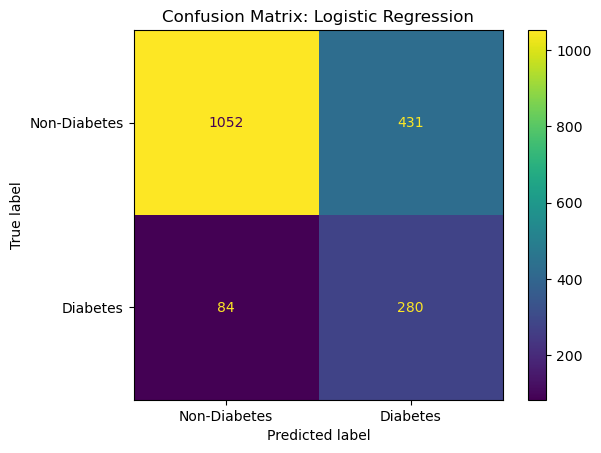

In [32]:
# Confusion matrix

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Diabetes", "Diabetes"]
)
disp.plot()
plt.title(f"Confusion Matrix: {best_model_name}")
plt.show()

### Confusion Matrix Interpretation

The confusion matrix shows the performance of the Logistic Regression model on the final holdout test set. The model correctly classified 1,052 non-diabetes participants and 280 diabetes participants. It missed 84 diabetes cases, which are false negatives, and incorrectly classified 431 non-diabetes participants as diabetes, which are false positives. For the diabetes screening goal, the most important result is that the model correctly identified 280 out of 364 actual diabetes cases, giving a diabetes recall of approximately 0.77. This indicates that the model captures most diabetes cases in the test set.

However, the model also produced 431 false positives, meaning some non-diabetes participants were flagged as diabetes risk. This reduces precision, but this tradeoff may be acceptable in an early screening setting where identifying possible high-risk individuals is more important than minimizing all false positives.

Overall, the confusion matrix shows that Logistic Regression is effective at detecting diabetes cases, but it also generates a moderate number of false positives.

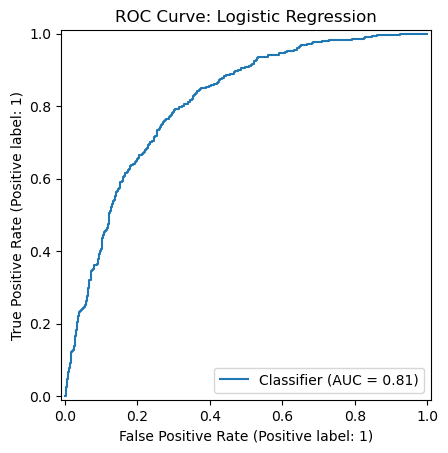

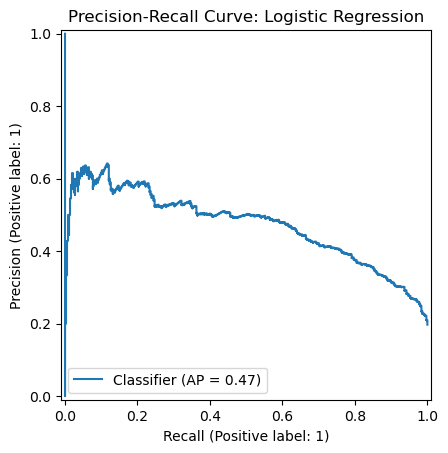

In [33]:
# ROC curve and PR curve

if y_test_prob is not None:
    RocCurveDisplay.from_predictions(y_test, y_test_prob)
    plt.title(f"ROC Curve: {best_model_name}")
    plt.show()

    PrecisionRecallDisplay.from_predictions(y_test, y_test_prob)
    plt.title(f"Precision-Recall Curve: {best_model_name}")
    plt.show()

### ROC and Precision-Recall Curve Interpretation

The ROC curve for the Logistic Regression model shows an AUC of approximately 0.81, indicating that the model has good ability to distinguish between diabetes and non-diabetes participants. Since a random classifier would have an ROC-AUC close to 0.50, the result suggests that the model is learning meaningful predictive signal.

The Precision-Recall curve shows an average precision of approximately 0.47. This is important because the dataset is imbalanced, with diabetes cases making up about 19.7% of the data. The average precision is substantially higher than the diabetes prevalence baseline, suggesting that the model performs better than random ranking for identifying diabetes cases.

The Precision-Recall curve also shows the tradeoff between recall and precision. As recall increases, precision decreases, meaning the model can identify more diabetes cases but will also produce more false positives. For an early diabetes screening task, this tradeoff may be acceptable because the goal is to detect high-risk individuals for further follow-up.

In [34]:
# Save the baseline test results 

test_results_path = modeling_dir / f"baselines_test_results_stratified.csv"
test_results_df.round(4).to_csv(test_results_path, index=False)

In [35]:
# stress test
# Shuffled target leakage check

y_train_shuffled = y_train.sample(frac=1, random_state=42).reset_index(drop=True)
X_train_reset = X_train.reset_index(drop=True)

shuffle_results = []

for model_name, model in models.items():
    print(f"Running shuffled-target check for: {model_name}")
    
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    cv_results = cross_validate(
        pipeline,
        X_train_reset,
        y_train_shuffled,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )
    
    row = {
        "model": model_name,
        "test_type": "shuffled_target"
    }
    
    for metric in scoring.keys():
        scores = cv_results[f"test_{metric}"]
        row[f"{metric}_mean"] = scores.mean()
        row[f"{metric}_std"] = scores.std()
    
    shuffle_results.append(row)

shuffle_results_df = pd.DataFrame(shuffle_results)
shuffle_results_df.round(4)

Running shuffled-target check for: Dummy Classifier
Running shuffled-target check for: Logistic Regression
Running shuffled-target check for: Decision Tree


,model,test_type,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,recall_mean,recall_std,precision_mean,precision_std,f1_mean,f1_std
0,Dummy Classifier,shuffled_target,0.8028,0.0003,0.5000,0.0000,0.5000,0.0000,0.1972,0.0003,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,Logistic Regression,shuffled_target,0.5066,0.0101,0.4992,0.0090,0.5040,0.0151,0.1997,0.0081,0.4870,0.0333,0.1965,0.0058,0.2798,0.0109
2,Decision Tree,shuffled_target,0.4450,0.0543,0.5098,0.0179,0.5041,0.0221,0.2012,0.0081,0.6168,0.1260,0.2008,0.0105,0.3011,0.0293


### Shuffled-Target Leakage Check

A shuffled-target experiment was performed as an adversarial leakage check. In this test, the diabetes labels were randomly shuffled and the models were evaluated using the same cross-validation framework.

After shuffling the target, the models performed close to random chance. The ROC-AUC values were approximately 0.50, the balanced accuracy values were approximately 0.50, and the PR-AUC values were close to the diabetes prevalence of about 19.7%. This is the expected behavior when the relationship between predictors and target is destroyed.

These results suggest that the evaluation pipeline does not show strong evidence of target leakage or artificial overfitting. The high accuracy of the Dummy Classifier is due to class imbalance and majority-class prediction, so accuracy alone is not a reliable metric for this screening problem.

In [36]:
# save the shuffle result 

shuffle_results_path = modeling_dir / f"shuffled_target_results_stratified.csv"
shuffle_results_df.round(4).to_csv(shuffle_results_path, index=False)

In [37]:
# subgroup performance 

def subgroup_recall_table(X_test, y_test, y_pred, group_col):
    temp = X_test.copy()
    temp["y_true"] = y_test.values
    temp["y_pred"] = y_pred
    
    rows = []
    
    for group_value, group_df in temp.groupby(group_col):
        if group_df["y_true"].nunique() < 2:
            continue
        
        rows.append({
            "group_column": group_col,
            "group_value": group_value,
            "n": len(group_df),
            "diabetes_cases": int(group_df["y_true"].sum()),
            "recall": recall_score(group_df["y_true"], group_df["y_pred"], zero_division=0),
            "precision": precision_score(group_df["y_true"], group_df["y_pred"], zero_division=0),
            "f1": f1_score(group_df["y_true"], group_df["y_pred"], zero_division=0),
            "balanced_accuracy": balanced_accuracy_score(group_df["y_true"], group_df["y_pred"])
        })
    
    return pd.DataFrame(rows)

In [38]:
subgroup_results = []

for group_col in ["RIAGENDR", "RIDRETH3", "DMDEDUC2"]:
    if group_col in X_test.columns:
        subgroup_results.append(
            subgroup_recall_table(X_test, y_test, y_test_pred, group_col)
        )
subgroup_results_df = pd.concat(subgroup_results, ignore_index=True)
subgroup_results_df

,group_column,group_value,n,diabetes_cases,recall,precision,f1,balanced_accuracy
0,RIAGENDR,1.0,893,196,0.795918,0.405195,0.537005,0.733684
1,RIAGENDR,2.0,954,168,0.738095,0.380368,0.502024,0.740549
2,RIDRETH3,1.0,210,50,0.860000,0.430000,0.573333,0.751875
3,RIDRETH3,2.0,179,43,0.720930,0.436620,0.543860,0.713406
4,RIDRETH3,3.0,679,113,0.761062,0.353909,0.483146,0.741838
5,RIDRETH3,4.0,466,98,0.775510,0.408602,0.535211,0.738299
6,RIDRETH3,6.0,217,46,0.695652,0.400000,0.507937,0.707475
7,RIDRETH3,7.0,96,14,0.857143,0.387097,0.533333,0.812718
8,DMDEDUC2,1.0,157,52,0.923077,0.406780,0.564706,0.628205
9,DMDEDUC2,2.0,206,49,0.857143,0.420000,0.563758,0.743858


### Subgroup Performance Stress Test

A subgroup performance analysis was conducted to evaluate whether the selected model performs consistently across demographic groups. Performance was examined by gender (`RIAGENDR`), race/ethnicity (`RIDRETH3`), and education level (`DMDEDUC2`).

The results show that model performance varies across subgroups. For gender, recall was slightly higher for `RIAGENDR = 1.0` than for `RIAGENDR = 2.0`, while balanced accuracy was almost similar across the two groups. For race/ethnicity, recall ranged from approximately 0.70 to 0.86, indicating that the model detects diabetes cases better in some groups than others. For education level, recall also varied, with lower recall observed for some higher education categories.

Some subgroup estimates should be interpreted carefully because certain groups have smaller sample sizes and fewer diabetes cases. For example, `RIDRETH3 = 7.0` had only 96 participants and 14 diabetes cases in the test set, so its performance estimates may be less stable.

Overall, the subgroup stress test shows that the model does not fail completely in any subgroup, but performance is not identical across groups. Since this project focuses on early diabetes risk screening, subgroup performance is important because overall metrics can hide weaker performance for specific participant groups. Future work may include further subgroup evaluation, threshold adjustment, or fairness-focused analysis.

In [39]:
# save the stress test-subgroup performance result 

subgroup_results_path = modeling_dir / f"subgroup_results_stratified.csv"
subgroup_results_df.round(4).to_csv(subgroup_results_path, index=False)